In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
rated_power = 3370
rated_wind_speed = 9.8
cut_in_wind_speed = 3
cut_out_wind_speed = 25
rotor_dia = 130
hub_height = 120

target_wind_dir = 240
weibull_c = 7.5
weibull_k = 2.72
turbine_working_hours = 1270

Y = 8760


In [3]:
df = pd.read_csv("/home/lavender/Studies/Design of Wind Farms/Assignment1/IEA_Reference_3.4MW_130.csv")

df.head(5)

,Wind Speed [m/s],Power [kW],Cp [-],Thrust [kN],Ct [-]
0,3.0000,51.620327,0.2368,59.159022,0.8140
1,3.5392,123.368159,0.3446,81.337534,0.8042
2,4.0485,213.241509,0.3980,105.641598,0.7982
3,4.5267,318.837998,0.4257,131.466695,0.7945
4,4.9730,435.956487,0.4390,158.022534,0.7913


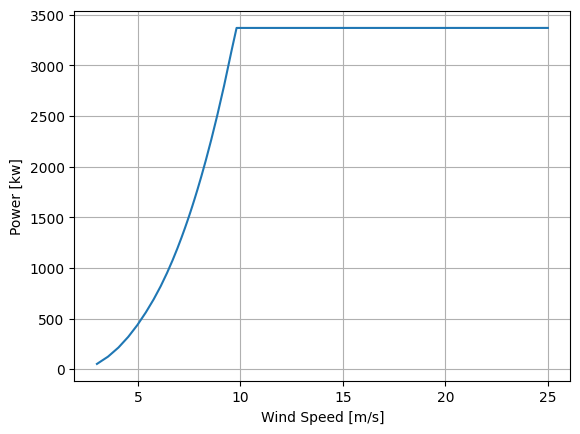

In [4]:
plt.plot(df["Wind Speed [m/s]"], df["Power [kW]"])
plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Power [kw]")
plt.grid()

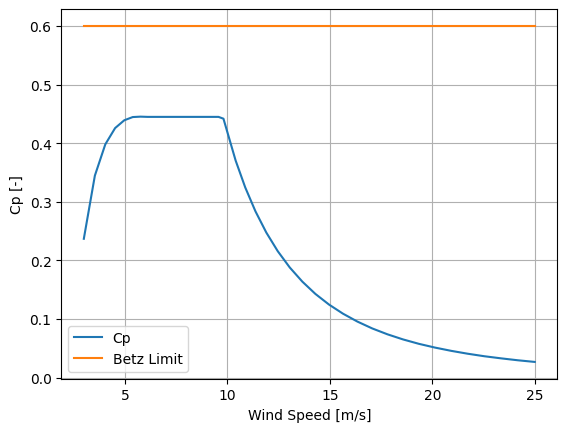

In [5]:
plt.plot(df["Wind Speed [m/s]"], df["Cp [-]"], label = "Cp")
plt.plot(df["Wind Speed [m/s]"], [0.6 for i in df["Wind Speed [m/s]"]], label = "Betz Limit")
plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Cp [-]")
plt.grid()
plt.legend()

In [6]:
def weibull_pdf(v, c=weibull_c, k=weibull_k):
    v = np.asarray(v, dtype=float)
    return (k / c) * (v / c) ** (k - 1) * np.exp(- (v / c) ** k)

In [7]:
v = df["Wind Speed [m/s]"].to_numpy()
P = df["Power [kW]"].to_numpy()


f = weibull_pdf(v)

mean_power = np.trapezoid(P * f, v)   # correct integration

mean_power

np.float64(1345.2059344857241)

In [8]:
AEP = turbine_working_hours * mean_power

AEP

np.float64(1708411.5367968697)

In [9]:
CF = mean_power / rated_power

CF

np.float64(0.39917090044086767)